# C-Case → R-Case match frequency over time

**Question.** Has the share of CA charges (C Cases) that we can link to an RC petition
(R Case) changed over the years — and if so, is the change *substantive* or an
*artifact* of the data being stitched together from three different NLRB filing
systems (CHIPS 1984–1999, CATS 2000–2010, NxGen 2011–2024)?

**Why this matters.** Our matched dataset is built from official datasets that were
collected under different schemas and over different eras. R-Case volume has declined
over the decades, so the *raw* number of matched C Cases will fall mechanically even if
matching works perfectly. To see whether matching itself degrades, we have to look at
**rates**, not counts, and we have to be careful about the **denominator**.

**The small-percentage problem.** Only a few percent of CA cases ever match an RC case
(most ULP charges have nothing to do with a concurrent organizing petition). Plotting
matched counts against the full universe would just show a flat line near zero. So the
plan is:

1. Show the **universe and its composition** by filing system over time (context).
2. Decompose the match rate into two interpretable pieces:
   - **eligibility rate** — share of CA cases that *can* match (usable company/city/state,
     not a union-name row) — this is the data-quality lever, and it is where filing-system
     differences would show up;
   - **conditional match rate** — among *eligible* CA cases, the share that actually match —
     this is the "does matching work" lever, normalised for data quality.
3. Plot rates per year with filing-system eras shaded, and compare the two matching
   methods (fuzzy vs cluster) side by side.
4. Break the rate down **by filing system** directly, which is the cleanest answer to
   "is a particular dataset a barrier?"

> **Read the years with care.** The two ends of the series are partly artifactual and are
> shaded grey in every time plot below — see section 1b. Only the central window
> (≈1985–2018) should be read at face value.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Notebook lives in match_rate_over_time/ ; data sits one level up.
DATA = Path("..")
assert (DATA / "merged_C_CASES_final.parquet").exists(), "Run this notebook from match_rate_over_time/"

# Matching outputs to compare. Add/remove here if filenames change.
METHODS = {
    "fuzzy":   DATA / "rc_ac_matches.parquet",
    "cluster": DATA / "rc_ac_cluster_matches_20260517.parquet",
}
METHOD_COLORS = {"fuzzy": "#1f77b4", "cluster": "#d62728"}

# Filing-system eras (for shading). Ranges per data_source in this dataset.
ERAS = [("CHIPS", 1984, 1999, "#4c72b0"),
        ("CATS",  2000, 2010, "#dd8452"),
        ("NxGen", 2011, 2024, "#55a868")]

YEAR_MIN, YEAR_MAX = 1963, 2024

# Start of the trustworthy window: CHIPS records before this are fragmentary
# (a few dozen RC cases/year with implausible multi-year "windows"). The
# recent censored boundary is computed from the data in section 1b.
TRUST_MIN = 1985
OPEN_FRAC_THRESH = 2.0  # %, RC-open share above which a recent year is "censored"


## 1. Load the CA universe and reconstruct matching eligibility

The matcher (`match_r_to_c_cases.py`) drops a CA case before matching when its address row is flagged as a union name or an over-long name, or when company / state / city is missing. A CA case that fails those filters **cannot** match under either method, so it belongs in the denominator only when we ask the raw question, not the conditional one. We rebuild that same eligibility flag here so the rates below are honest.

In [2]:
# ---- CA universe (one row per CA case) ----
c_final = pd.read_parquet(DATA / "merged_C_CASES_final.parquet")
c_final = c_final[c_final["type"] == "CA"].copy()
c_final = c_final.rename(columns={"case_number": "c_case_number"})
c_final["date_filed"] = pd.to_datetime(c_final["date_filed"], errors="coerce")
c_final["year"] = c_final["date_filed"].dt.year

# ---- Address table: derive the matcher's eligibility filter ----
c_addr = pd.read_parquet(DATA / "merged_C_CASES_ADDRESS_with_union_flag.parquet")
c_addr = c_addr.rename(columns={"case_number": "c_case_number"})
c_addr = c_addr.drop_duplicates(subset=["c_case_number"], keep="first")

def _norm(s):
    s = s.fillna("").astype(str).str.lower().str.strip()
    for ch in [".", ",", "'", '"']:
        s = s.str.replace(ch, "", regex=False)
    return s.str.replace(r"\s+", " ", regex=True)

flagged = c_addr["is_union_name"].fillna(False) | c_addr["is_long_name"].fillna(False)
has_company = _norm(c_addr["company_name"]) != ""
has_state   = _norm(c_addr["state"]) != ""
has_city    = _norm(c_addr["city"]) != ""
c_addr["eligible"] = (~flagged) & has_company & has_state & has_city

# Attach eligibility to the universe. A CA case with no usable address row is not eligible.
c_final = c_final.merge(c_addr[["c_case_number", "eligible"]], on="c_case_number", how="left")
c_final["eligible"] = c_final["eligible"].fillna(False)

# Keep a clean, dated universe.
universe = c_final.dropna(subset=["year"]).copy()
universe = universe[(universe["year"] >= YEAR_MIN) & (universe["year"] <= YEAR_MAX)]
universe["year"] = universe["year"].astype(int)

print(f"CA cases (typed CA, dated):     {len(universe):,}")
print(f"  eligible for matching:        {universe['eligible'].sum():,} "
      f"({100*universe['eligible'].mean():.1f}%)")
print("\nBy filing system:")
display(universe.groupby("data_source")["eligible"].agg(
    n="size", eligible="sum", elig_rate="mean").assign(elig_rate=lambda d: (100*d.elig_rate).round(1)))


CA cases (typed CA, dated):     771,459
  eligible for matching:        754,053 (97.7%)

By filing system:


,n,eligible,elig_rate
data_source,,,
CATS,233941,230404,98.5
CHIPS,348873,339320,97.3
NxGen,188645,184329,97.7


## 1b. Which years can we trust? (data ramp + right-censoring)

Two ends of the time series are **not** reliable and would mislead anyone who reads the charts without the text:

- **Pre-1985 — data ramp.** CHIPS coverage is fragmentary before ~1984: only a few dozen RC petitions per year with implausibly long recorded windows. The apparent *rise* in match rate toward the 1990 peak is mostly records coming online, not a real increase in match propensity.
- **Recent years — right-censoring.** The matcher drops RC cases with no `date_closed` (still open). The open share is ~0 historically but spikes at the recent end, so recent CA charges lose RC windows to match into and their match rate is biased **downward**. The final year is also a partial year.

We compute the censored boundary from the RC data and shade both regions grey in every time plot below.

In [3]:
# Load RC cases once (reused in section 7). Compute the per-year open fraction
# so the censored recent region is data-driven, not hard-coded.
r_final = pd.read_parquet(DATA / "merged_R_CASES_final.parquet")
r_final = r_final[r_final["type"] == "RC"].copy()
r_final["date_filed"]  = pd.to_datetime(r_final["date_filed"], errors="coerce")
r_final["date_closed"] = pd.to_datetime(r_final["date_closed"], errors="coerce")
r_final["year"] = r_final["date_filed"].dt.year
r_dated = r_final.dropna(subset=["year"]).copy()
r_dated["year"] = r_dated["year"].astype(int)
r_dated = r_dated[(r_dated["year"] >= YEAR_MIN) & (r_dated["year"] <= YEAR_MAX)]

rc_open_frac = r_dated.assign(open=r_dated["date_closed"].isna()).groupby("year")["open"].mean() * 100

# Censored region = recent (>=2015) years whose RC-open share exceeds the threshold.
recent_open = rc_open_frac[(rc_open_frac.index >= 2015) & (rc_open_frac > OPEN_FRAC_THRESH)]
CENSOR_START = int(recent_open.index.min()) if len(recent_open) else YEAR_MAX
PARTIAL_YEAR = YEAR_MAX

print(f"Trustworthy window: {TRUST_MIN}–{CENSOR_START - 1}")
print(f"  pre-{TRUST_MIN}: CHIPS data ramp (fragmentary)")
print(f"  {CENSOR_START}+: RC-open share > {OPEN_FRAC_THRESH}% -> right-censored")
print("\nRC-open share, recent years (%):")
print(rc_open_frac[rc_open_frac.index >= 2015].round(1).to_string())

def shade_eras(ax):
    for label, lo, hi, col in ERAS:
        ax.axvspan(lo, hi, color=col, alpha=0.06)
    for x in [1999.5, 2010.5]:
        ax.axvline(x, color="grey", ls="--", lw=0.8, alpha=0.6)

def mark_untrusted(ax, label=True):
    """Grey out the pre-1985 data ramp and the recent right-censored tail."""
    ax.axvspan(YEAR_MIN, TRUST_MIN, color="0.5", alpha=0.20, zorder=0)
    ax.axvspan(CENSOR_START - 0.5, YEAR_MAX, color="0.5", alpha=0.20, hatch="///",
               edgecolor="0.4", zorder=0)
    if label:
        y = ax.get_ylim()[1]
        ax.text((YEAR_MIN + TRUST_MIN) / 2, y * 0.5, "data\nramp",
                ha="center", va="center", fontsize=8, color="0.3", style="italic")
        ax.text((CENSOR_START + YEAR_MAX) / 2, y * 0.5, "censored",
                ha="center", va="center", fontsize=8, color="0.3", style="italic", rotation=90)


Trustworthy window: 1985–2021
  pre-1985: CHIPS data ramp (fragmentary)
  2022+: RC-open share > 2.0% -> right-censored

RC-open share, recent years (%):
year
2015     0.1
2016     0.1
2017     0.1
2018     0.1
2019     0.1
2020     0.5
2021     0.9
2022     3.2
2023     8.0
2024    44.5


## 2. Load matched CA cases for each method

We attribute a match to the **year the CA charge was filed** (`c_date_filed`), which is the same clock the universe is counted on. A CA case that matches several RC cases is counted once (distinct `c_case_number`).

In [4]:
matched = {}   # method -> set of matched c_case_number
matched_year = {}  # method -> DataFrame[c_case_number, year]

for name, path in METHODS.items():
    m = pd.read_parquet(path)
    m["c_date_filed"] = pd.to_datetime(m["c_date_filed"], errors="coerce")
    mm = m.dropna(subset=["c_date_filed"]).drop_duplicates("c_case_number").copy()
    mm["year"] = mm["c_date_filed"].dt.year.astype(int)
    matched[name] = set(mm["c_case_number"])
    matched_year[name] = mm[["c_case_number", "year"]]
    overlap = universe["c_case_number"].isin(matched[name]).sum()
    print(f"{name:>8s}: {len(matched[name]):>7,} distinct matched CA cases "
          f"({overlap:,} found in the dated universe)")


   fuzzy:  45,824 distinct matched CA cases (45,824 found in the dated universe)
 cluster:  54,697 distinct matched CA cases (54,697 found in the dated universe)


## 3. Build the per-year, per-method rate table

For each year we compute three quantities per method:

- **raw match rate** = matched CA / all CA filed that year
- **eligibility rate** = eligible CA / all CA filed that year (method-independent)
- **conditional match rate** = matched CA / eligible CA that year

`raw = eligibility × conditional`, so the decomposition is exact and lets us attribute any year-over-year movement to data quality vs. matching reach.

In [5]:
tot_by_year  = universe.groupby("year").size().rename("n_total")
elig_by_year = universe.groupby("year")["eligible"].sum().rename("n_eligible")

eligible_ids = set(universe.loc[universe["eligible"], "c_case_number"])

rows = []
years = range(YEAR_MIN, YEAR_MAX + 1)
for name in METHODS:
    my = matched_year[name].copy()
    my = my[my["c_case_number"].isin(set(universe["c_case_number"]))]  # confine to dated universe
    matched_by_year = my.groupby("year").size().rename("n_matched")
    # matched AND eligible (numerator for the conditional rate)
    my_elig = my[my["c_case_number"].isin(eligible_ids)]
    matched_elig_by_year = my_elig.groupby("year").size().rename("n_matched_eligible")
    df = pd.DataFrame(index=years).join([tot_by_year, elig_by_year,
                                         matched_by_year, matched_elig_by_year]).fillna(0)
    df["method"] = name
    rows.append(df)

rate = pd.concat(rows).reset_index().rename(columns={"index": "year"})
for c in ["n_total", "n_eligible", "n_matched", "n_matched_eligible"]:
    rate[c] = rate[c].astype(int)
rate["raw_rate"]         = 100 * rate["n_matched"]          / rate["n_total"].where(rate["n_total"] > 0)
rate["elig_rate"]        = 100 * rate["n_eligible"]         / rate["n_total"].where(rate["n_total"] > 0)
rate["conditional_rate"] = 100 * rate["n_matched_eligible"] / rate["n_eligible"].where(rate["n_eligible"] > 0)

rate.head(12)


,year,n_total,n_eligible,n_matched,n_matched_eligible,method,raw_rate,elig_rate,conditional_rate
0,1963,1,1,0,0,fuzzy,0.0,100.000000,0.0
1,1964,0,0,0,0,fuzzy,NaN,NaN,NaN
2,1965,4,4,0,0,fuzzy,0.0,100.000000,0.0
3,1966,3,2,0,0,fuzzy,0.0,66.666667,0.0
4,1967,2,2,0,0,fuzzy,0.0,100.000000,0.0
5,1968,3,2,0,0,fuzzy,0.0,66.666667,0.0
6,1969,3,3,0,0,fuzzy,0.0,100.000000,0.0
7,1970,8,8,0,0,fuzzy,0.0,100.000000,0.0
8,1971,6,5,0,0,fuzzy,0.0,83.333333,0.0
9,1972,18,16,0,0,fuzzy,0.0,88.888889,0.0


## 4. Context: the CA universe and its filing-system composition

Before any rates, see the raw material. The stacked area shows how many CA charges were filed each year and which filing system they came from. The seams between systems (and the overlap years, where two systems coexist) are exactly the places a stitching artifact would appear.

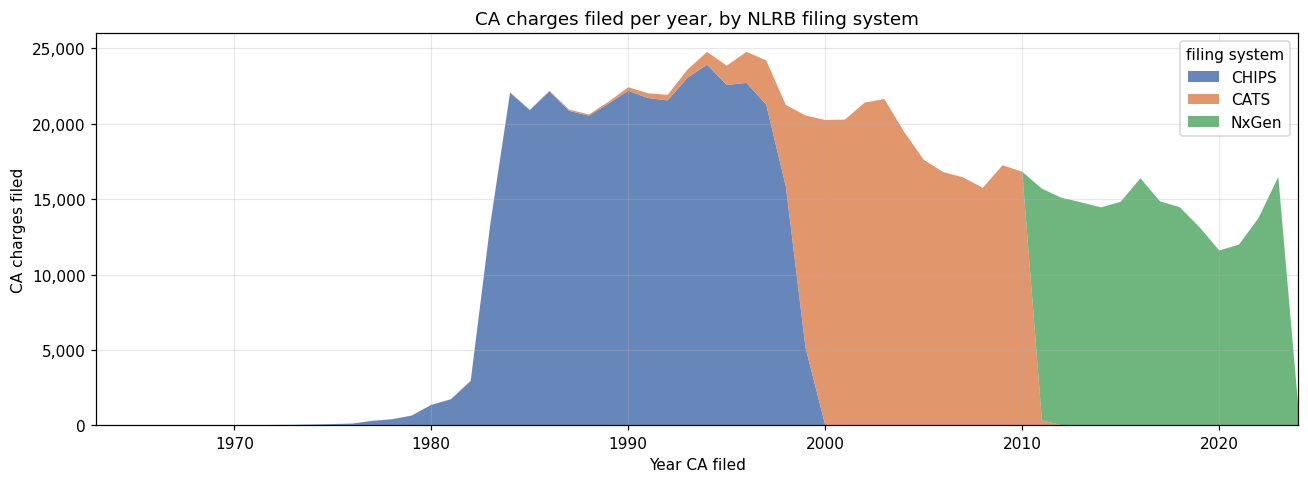

In [6]:
comp = (universe.groupby(["year", "data_source"]).size()
        .unstack("data_source").reindex(range(YEAR_MIN, YEAR_MAX + 1)).fillna(0))
order = [e[0] for e in ERAS if e[0] in comp.columns]
comp = comp[order]

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = {e[0]: e[3] for e in ERAS}
ax.stackplot(comp.index, *[comp[c] for c in comp.columns],
             labels=comp.columns, colors=[colors[c] for c in comp.columns], alpha=0.85)
ax.set_title("CA charges filed per year, by NLRB filing system")
ax.set_xlabel("Year CA filed"); ax.set_ylabel("CA charges filed")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper right", title="filing system")
ax.set_xlim(YEAR_MIN, YEAR_MAX)
plt.tight_layout(); plt.show()


Note the overlap years (e.g. CATS begins while CHIPS is still running; NxGen begins as CATS winds down). A CA case sits in exactly one `data_source`, so these are genuine handoffs, not double counts — but they are the natural suspects for any rate discontinuity below.

## 5. The headline: match rate per year (raw)

This is the number the project cares about — of all CA charges filed in a year, what share we link to an RC petition. Both methods shown; filing-system eras shaded faintly, and the untrustworthy ends (pre-1985 ramp, recent censored tail) greyed out. Because the rate is a share, the long-run decline in case volume is divided out.

C:\Users\PsyLab-9221\AppData\Local\Temp\ipykernel_147356\617954233.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(CENSOR_START - 0.5, YEAR_MAX, color="0.5", alpha=0.20, hatch="///",


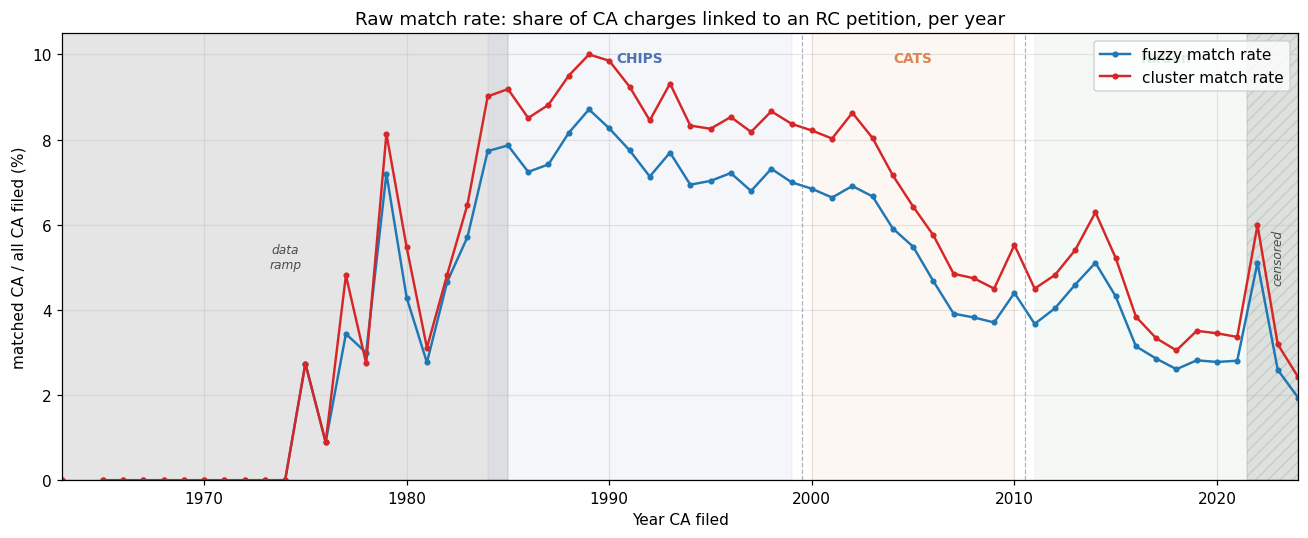

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in METHODS:
    d = rate[rate["method"] == name]
    ax.plot(d["year"], d["raw_rate"], marker="o", ms=3, lw=1.6,
            color=METHOD_COLORS[name], label=f"{name} match rate")
shade_eras(ax)
ax.set_title("Raw match rate: share of CA charges linked to an RC petition, per year")
ax.set_xlabel("Year CA filed"); ax.set_ylabel("matched CA / all CA filed (%)")
ax.set_xlim(YEAR_MIN, YEAR_MAX); ax.set_ylim(bottom=0)
ax.legend(loc="upper right")
mark_untrusted(ax)
# annotate era labels along the top
ymax = ax.get_ylim()[1]
for label, lo, hi, col in ERAS:
    ax.text((max(lo, YEAR_MIN) + min(hi, YEAR_MAX)) / 2, ymax * 0.96, label,
            ha="center", va="top", fontsize=9, color=col, fontweight="bold")
plt.tight_layout(); plt.show()


Inside the trustworthy window the story is clean: the rate peaks around 1990 (~8%) and declines steadily to ~4% by the late 2010s. The grey ends are shown for completeness but should not be read as trend — the left is data coming online, the right is censoring.

## 6. Decomposition: is a dip data-quality or matching reach?

The raw rate mixes two effects. The left panel is the **eligibility rate** (method-independent): if a filing system stored worse company/city data, or flagged more rows, this line drops and drags the raw rate down with it — a pure data artifact. The right panel is the **conditional match rate** among eligible cases: this is matching reach with data quality held constant. If the conditional rate is stable across eras, the matching method is *not* the barrier.

C:\Users\PsyLab-9221\AppData\Local\Temp\ipykernel_147356\617954233.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(CENSOR_START - 0.5, YEAR_MAX, color="0.5", alpha=0.20, hatch="///",


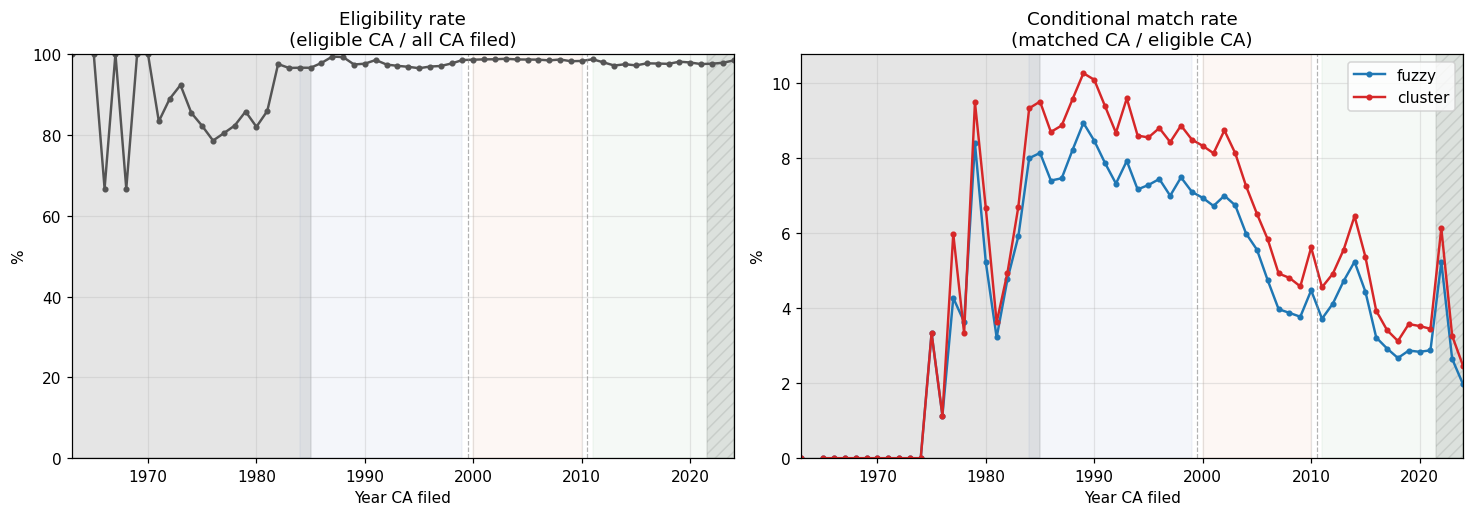

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)

# Left: eligibility rate (same for both methods -> take one)
elig = rate[rate["method"] == list(METHODS)[0]]
axes[0].plot(elig["year"], elig["elig_rate"], color="#555555", marker="o", ms=3, lw=1.6)
shade_eras(axes[0])
axes[0].set_title("Eligibility rate\n(eligible CA / all CA filed)")
axes[0].set_xlabel("Year CA filed"); axes[0].set_ylabel("%")
axes[0].set_ylim(0, 100)

# Right: conditional match rate per method
for name in METHODS:
    d = rate[rate["method"] == name]
    axes[1].plot(d["year"], d["conditional_rate"], marker="o", ms=3, lw=1.6,
                 color=METHOD_COLORS[name], label=name)
shade_eras(axes[1])
axes[1].set_title("Conditional match rate\n(matched CA / eligible CA)")
axes[1].set_xlabel("Year CA filed"); axes[1].set_ylabel("%")
axes[1].set_ylim(bottom=0); axes[1].legend(loc="upper right")

for ax in axes:
    ax.set_xlim(YEAR_MIN, YEAR_MAX)
    mark_untrusted(ax, label=False)
plt.tight_layout(); plt.show()


**How to read this.** If the raw rate (section 5) dips at a system seam but the *conditional* rate (right) stays flat, the dip is a data-quality / eligibility artifact of that filing system, not a failure of matching. If instead the conditional rate itself moves at the seam, matching reach genuinely differs across eras and deserves a closer look. Here eligibility is high and flat (~98%) right across the trustworthy window with no seam discontinuity, so the decline in the raw rate lives in the conditional rate — i.e. it is substantive, not a merge artifact.

## 7. The other half of the denominator: RC supply

A CA case can only match if an RC petition's open window overlaps it. RC filings have declined for decades, so even a perfect matcher would link fewer CA cases simply because there are fewer RC windows to land in. Here we overlay RC filings per year against the matched-CA count, to separate 'matching got worse' from 'there were fewer petitions to match'.

C:\Users\PsyLab-9221\AppData\Local\Temp\ipykernel_147356\617954233.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(CENSOR_START - 0.5, YEAR_MAX, color="0.5", alpha=0.20, hatch="///",


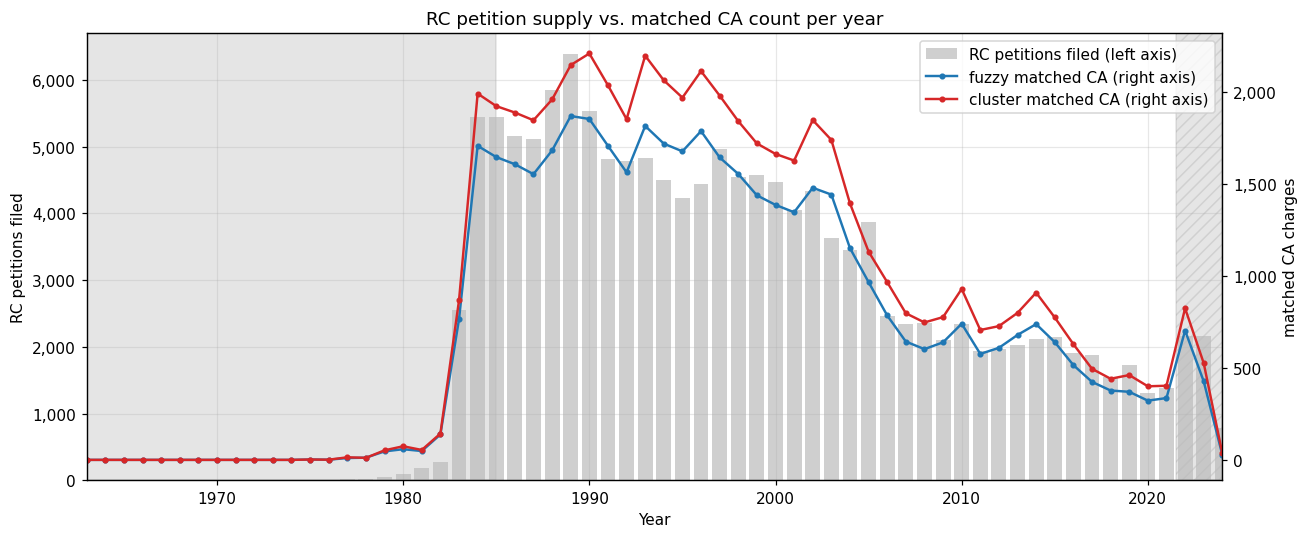

In [9]:
rc_by_year = r_dated.groupby("year").size()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(rc_by_year.index, rc_by_year.values, color="#bbbbbb", alpha=0.7,
        label="RC petitions filed (left axis)")
ax1.set_xlabel("Year"); ax1.set_ylabel("RC petitions filed")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2 = ax1.twinx(); ax2.grid(False)
for name in METHODS:
    d = rate[rate["method"] == name]
    ax2.plot(d["year"], d["n_matched"], marker="o", ms=3, lw=1.6,
             color=METHOD_COLORS[name], label=f"{name} matched CA (right axis)")
ax2.set_ylabel("matched CA charges")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax1.set_xlim(YEAR_MIN, YEAR_MAX)
mark_untrusted(ax1, label=False)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper right")
ax1.set_title("RC petition supply vs. matched CA count per year")
plt.tight_layout(); plt.show()


If matched-CA counts track RC supply closely, the long-run decline in matches is mostly the decline in organizing petitions — a real-world trend, not a data-stitching problem. The `CA_per_RC` ratio rising over time (RC falling faster than CA) is exactly why the *rate*, not just the count, drifts down through the trustworthy window.

## 8. Direct answer: match rate by filing system

Collapsing time, this is the cleanest test of 'is a particular NLRB dataset a barrier to matching?' We compare raw and conditional rates per `data_source`. If conditional rates are similar across the three systems, the merge is not biasing matching; differences in the raw rate are then attributable to eligibility (data quality) differences.

,data_source,method,n_total,n_eligible,raw_rate,elig_rate,conditional_rate
0,CHIPS,fuzzy,348873,339320,7.41,97.26,7.62
1,CHIPS,cluster,348873,339320,8.74,97.26,8.99
2,CATS,fuzzy,233941,230404,5.65,98.49,5.74
3,CATS,cluster,233941,230404,6.87,98.49,6.98
4,NxGen,fuzzy,188645,184329,3.57,97.71,3.66
5,NxGen,cluster,188645,184329,4.31,97.71,4.41


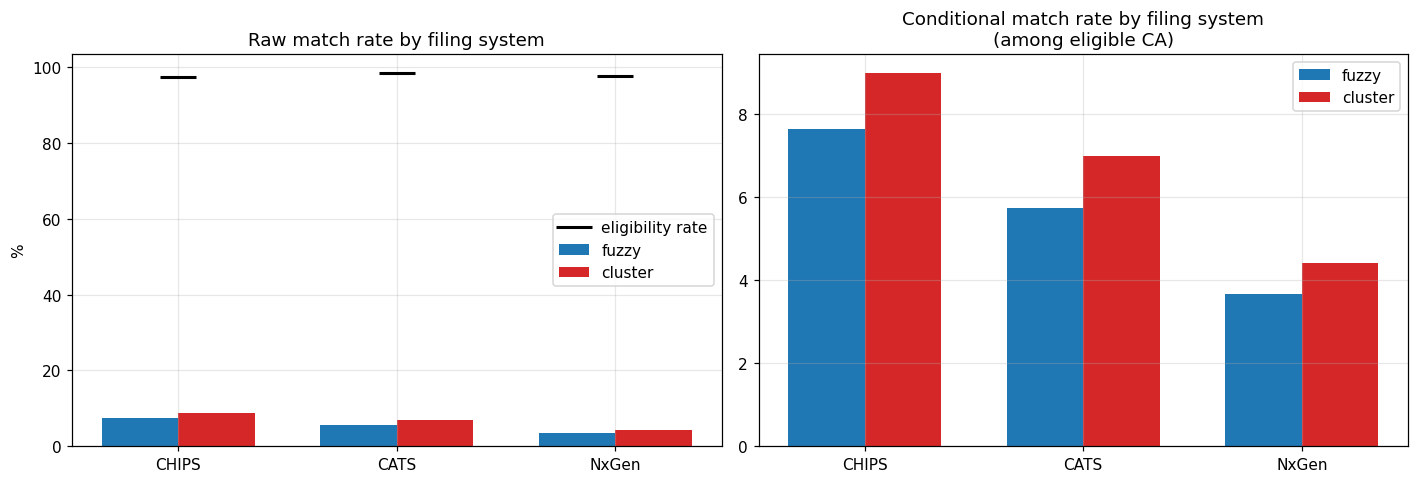

In [10]:
src_rows = []
for src in [e[0] for e in ERAS]:
    u = universe[universe["data_source"] == src]
    n_tot = len(u); n_elig = int(u["eligible"].sum())
    elig_ids_src = set(u.loc[u["eligible"], "c_case_number"])
    ids_src = set(u["c_case_number"])
    for name in METHODS:
        n_match = len(matched[name] & ids_src)
        n_match_elig = len(matched[name] & elig_ids_src)
        src_rows.append(dict(
            data_source=src, method=name, n_total=n_tot, n_eligible=n_elig,
            raw_rate=100*n_match/n_tot if n_tot else np.nan,
            elig_rate=100*n_elig/n_tot if n_tot else np.nan,
            conditional_rate=100*n_match_elig/n_elig if n_elig else np.nan))
by_src = pd.DataFrame(src_rows)
display(by_src.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
srcs = [e[0] for e in ERAS]; x = np.arange(len(srcs)); w = 0.35
for i, name in enumerate(METHODS):
    sub = by_src[by_src["method"] == name].set_index("data_source").reindex(srcs)
    axes[0].bar(x + (i-0.5)*w, sub["raw_rate"], w, color=METHOD_COLORS[name], label=name)
    axes[1].bar(x + (i-0.5)*w, sub["conditional_rate"], w, color=METHOD_COLORS[name], label=name)
# eligibility (method-independent) as a reference line on the raw panel
elig_ref = by_src.drop_duplicates("data_source").set_index("data_source").reindex(srcs)["elig_rate"]
axes[0].plot(x, elig_ref.values, "k_", ms=24, mew=2, label="eligibility rate")
axes[0].set_title("Raw match rate by filing system"); axes[0].set_ylabel("%")
axes[1].set_title("Conditional match rate by filing system\n(among eligible CA)")
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(srcs); ax.legend()
plt.tight_layout(); plt.show()


Caveat for this view: NxGen spans the right-censored recent years, so its rate is pulled down by open RC windows, and CHIPS includes the pre-1985 ramp. The per-system bars are still useful for eligibility (a pure data-quality measure), but read the system-level *match* rates with the same end-of-series caution as the time plots.

## 9. Summary table and takeaways

Per-decade view to keep the numbers legible, plus the by-system rates above. Use this to state, in the writeup, whether the matched-CA trend is driven by (a) declining RC supply, (b) filing-system eligibility differences, or (c) genuine differences in matching reach.

In [11]:
dec = rate.copy()
dec["decade"] = (dec["year"] // 10 * 10).astype(int)
summary = (dec.groupby(["decade", "method"])
           .agg(n_total=("n_total", "sum"), n_eligible=("n_eligible", "sum"),
                n_matched=("n_matched", "sum"), n_matched_eligible=("n_matched_eligible", "sum"))
           .reset_index())
summary["raw_rate_%"]         = (100*summary["n_matched"]/summary["n_total"]).round(2)
summary["elig_rate_%"]        = (100*summary["n_eligible"]/summary["n_total"]).round(1)
summary["conditional_rate_%"] = (100*summary["n_matched_eligible"]/summary["n_eligible"]).round(2)
display(summary)

# Save the per-year rate table for the writeup / further analysis.
out = Path("ca_match_rate_by_year.csv")
rate.sort_values(["method", "year"]).to_csv(out, index=False)
print("Saved", out.resolve())


,decade,method,n_total,n_eligible,n_matched,n_matched_eligible,raw_rate_%,elig_rate_%,conditional_rate_%
0,1960,cluster,16,14,0,0,0.00,87.5,0.00
1,1960,fuzzy,16,14,0,0,0.00,87.5,0.00
2,1970,cluster,1622,1354,80,80,4.93,83.5,5.91
3,1970,fuzzy,1622,1354,71,71,4.38,83.5,5.24
4,1980,cluster,147707,143868,12891,12891,8.73,97.4,8.96
5,1980,fuzzy,147707,143868,11073,11073,7.50,97.4,7.70
6,1990,cluster,229397,223338,19980,19980,8.71,97.4,8.95
7,1990,fuzzy,229397,223338,16757,16757,7.30,97.4,7.50
8,2000,cluster,186928,184305,12688,12688,6.79,98.6,6.88
9,2000,fuzzy,186928,184305,10439,10439,5.58,98.6,5.66


Saved C:\Users\PsyLab-9221\Documents\NLRB_project\nlrb-matching-cases\match_rate_over_time\ca_match_rate_by_year.csv


## 10. R-side: share of RC petitions with ≥1 CA match over time

Sections 5–9 are **C-side** (of all CA charges, what share link to an RC petition). This is the
mirror-image **R-side** question: of all RC petitions *filed* in a year, what share picked up at
least one CA charge inside their window?

One extra wrinkle vs. the C-side. The matcher drops RC cases with no `date_closed` (an open case
has no window for a CA to fall inside), so on the R-side "eligibility" folds in **has a close
date** *and* the usual address filter (not a union/over-long name; non-empty company/state/city).
That is why recent years sag — the same right-censoring from section 1b, now acting on the
denominator directly. The decomposition `raw = eligibility × conditional` makes it explicit.

Petitions are attributed to the year they were **filed** (`r_date_filed`).

In [12]:
# ---- R-side eligibility (mirror of the C-side filter, plus has_closed) ----
r_addr = pd.read_parquet(DATA / "merged_R_CASES_ADDRESS_with_union_flag.parquet")
r_addr = r_addr.rename(columns={"case_number": "r_case_number"})
r_addr = r_addr.drop_duplicates(subset=["r_case_number"], keep="first")
flagged_r = r_addr["is_union_name"].fillna(False) | r_addr["is_long_name"].fillna(False)
r_addr["addr_ok"] = ((~flagged_r)
                     & (_norm(r_addr["company_name"]) != "")
                     & (_norm(r_addr["state"]) != "")
                     & (_norm(r_addr["city"]) != ""))

# RC universe (RC-type, dated, in range) from section 1b's r_dated.
rc_uni = r_dated.rename(columns={"case_number": "r_case_number"}).copy()
rc_uni["has_closed"] = rc_uni["date_closed"].notna()
rc_uni = rc_uni.merge(r_addr[["r_case_number", "addr_ok"]], on="r_case_number", how="left")
rc_uni["addr_ok"] = rc_uni["addr_ok"].fillna(False)
rc_uni["eligible"] = rc_uni["addr_ok"] & rc_uni["has_closed"]   # matcher's real prerequisites

print(f"RC petitions (RC-type, dated):  {len(rc_uni):,}")
print(f"  with a close date:            {rc_uni['has_closed'].sum():,} "
      f"({100*rc_uni['has_closed'].mean():.1f}%)")
print(f"  eligible (closed + address):  {rc_uni['eligible'].sum():,} "
      f"({100*rc_uni['eligible'].mean():.1f}%)")

# ---- Matched RC sets per method (distinct r_case_number, by r_date_filed year) ----
matched_r, matched_r_year = {}, {}
for name, path in METHODS.items():
    m = pd.read_parquet(path)
    m["r_date_filed"] = pd.to_datetime(m["r_date_filed"], errors="coerce")
    mm = m.dropna(subset=["r_date_filed"]).drop_duplicates("r_case_number").copy()
    mm["year"] = mm["r_date_filed"].dt.year.astype(int)
    matched_r[name] = set(mm["r_case_number"])
    matched_r_year[name] = mm[["r_case_number", "year"]]
    print(f"{name:>8s}: {len(matched_r[name]):>7,} distinct RC petitions with >=1 CA match")


RC petitions (RC-type, dated):  144,319
  with a close date:            143,607 (99.5%)
  eligible (closed + address):  141,034 (97.7%)
   fuzzy:  25,539 distinct RC petitions with >=1 CA match
 cluster:  29,157 distinct RC petitions with >=1 CA match


In [13]:
# ---- Per-year, per-method R-side rate table ----
rc_ids      = set(rc_uni["r_case_number"])
elig_rc_ids = set(rc_uni.loc[rc_uni["eligible"], "r_case_number"])
tot_r  = rc_uni.groupby("year").size().rename("n_total")
elig_r = rc_uni.groupby("year")["eligible"].sum().rename("n_eligible")

rows = []
for name in METHODS:
    my = matched_r_year[name]
    my = my[my["r_case_number"].isin(rc_ids)]
    nm  = my.groupby("year").size().rename("n_matched")
    nme = my[my["r_case_number"].isin(elig_rc_ids)].groupby("year").size().rename("n_matched_eligible")
    df = pd.DataFrame(index=range(YEAR_MIN, YEAR_MAX + 1)).join([tot_r, elig_r, nm, nme]).fillna(0)
    df["method"] = name
    rows.append(df)

rate_r = pd.concat(rows).reset_index().rename(columns={"index": "year"})
for c in ["n_total", "n_eligible", "n_matched", "n_matched_eligible"]:
    rate_r[c] = rate_r[c].astype(int)
rate_r["raw_rate"]         = 100 * rate_r["n_matched"]          / rate_r["n_total"].where(rate_r["n_total"] > 0)
rate_r["elig_rate"]        = 100 * rate_r["n_eligible"]         / rate_r["n_total"].where(rate_r["n_total"] > 0)
rate_r["conditional_rate"] = 100 * rate_r["n_matched_eligible"] / rate_r["n_eligible"].where(rate_r["n_eligible"] > 0)
rate_r.head(12)


,year,n_total,n_eligible,n_matched,n_matched_eligible,method,raw_rate,elig_rate,conditional_rate
0,1963,0,0,0,0,fuzzy,NaN,NaN,NaN
1,1964,0,0,0,0,fuzzy,NaN,NaN,NaN
2,1965,0,0,0,0,fuzzy,NaN,NaN,NaN
3,1966,0,0,0,0,fuzzy,NaN,NaN,NaN
4,1967,0,0,0,0,fuzzy,NaN,NaN,NaN
5,1968,0,0,0,0,fuzzy,NaN,NaN,NaN
6,1969,0,0,0,0,fuzzy,NaN,NaN,NaN
7,1970,0,0,0,0,fuzzy,NaN,NaN,NaN
8,1971,0,0,0,0,fuzzy,NaN,NaN,NaN
9,1972,0,0,0,0,fuzzy,NaN,NaN,NaN


**Headline R-side rate.** Share of RC petitions filed each year with at least one CA match. Untrustworthy ends greyed as before.

C:\Users\PsyLab-9221\AppData\Local\Temp\ipykernel_147356\617954233.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(CENSOR_START - 0.5, YEAR_MAX, color="0.5", alpha=0.20, hatch="///",


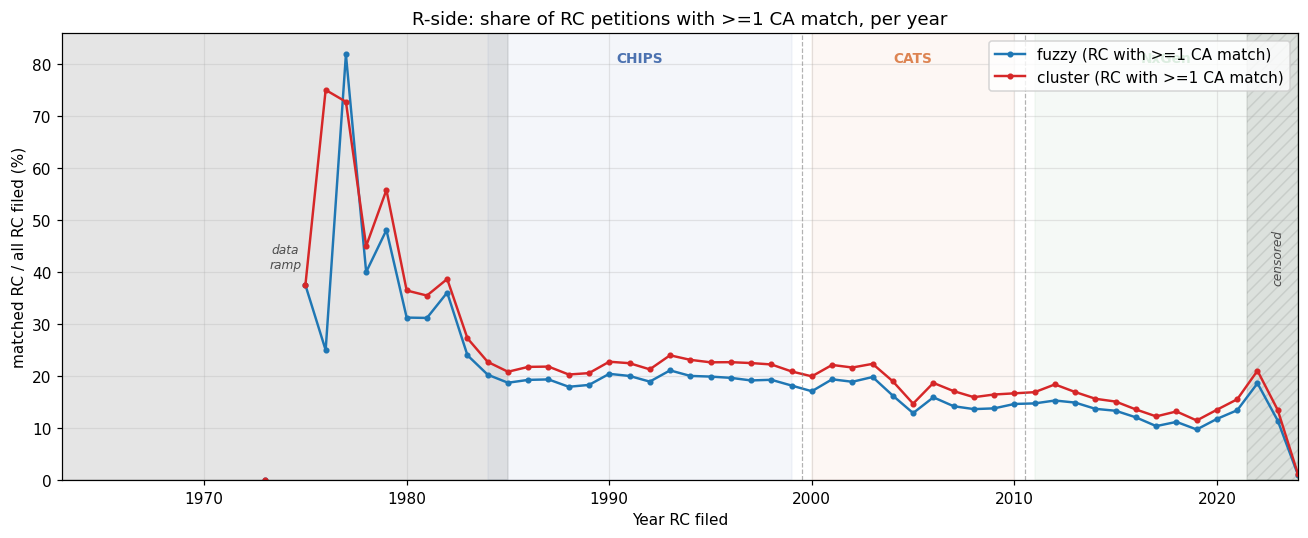

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in METHODS:
    d = rate_r[rate_r["method"] == name]
    ax.plot(d["year"], d["raw_rate"], marker="o", ms=3, lw=1.6,
            color=METHOD_COLORS[name], label=f"{name} (RC with >=1 CA match)")
shade_eras(ax)
ax.set_title("R-side: share of RC petitions with >=1 CA match, per year")
ax.set_xlabel("Year RC filed"); ax.set_ylabel("matched RC / all RC filed (%)")
ax.set_xlim(YEAR_MIN, YEAR_MAX); ax.set_ylim(bottom=0)
ax.legend(loc="upper right")
mark_untrusted(ax)
ymax = ax.get_ylim()[1]
for label, lo, hi, col in ERAS:
    ax.text((max(lo, YEAR_MIN) + min(hi, YEAR_MAX)) / 2, ymax * 0.96, label,
            ha="center", va="top", fontsize=9, color=col, fontweight="bold")
plt.tight_layout(); plt.show()


**Decomposition.** Left = eligibility (closed window + usable address); this is where the recent right-censoring bites the R-side denominator. Right = conditional rate among eligible petitions — the matching reach once open/unusable RC cases are set aside.

C:\Users\PsyLab-9221\AppData\Local\Temp\ipykernel_147356\617954233.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(CENSOR_START - 0.5, YEAR_MAX, color="0.5", alpha=0.20, hatch="///",


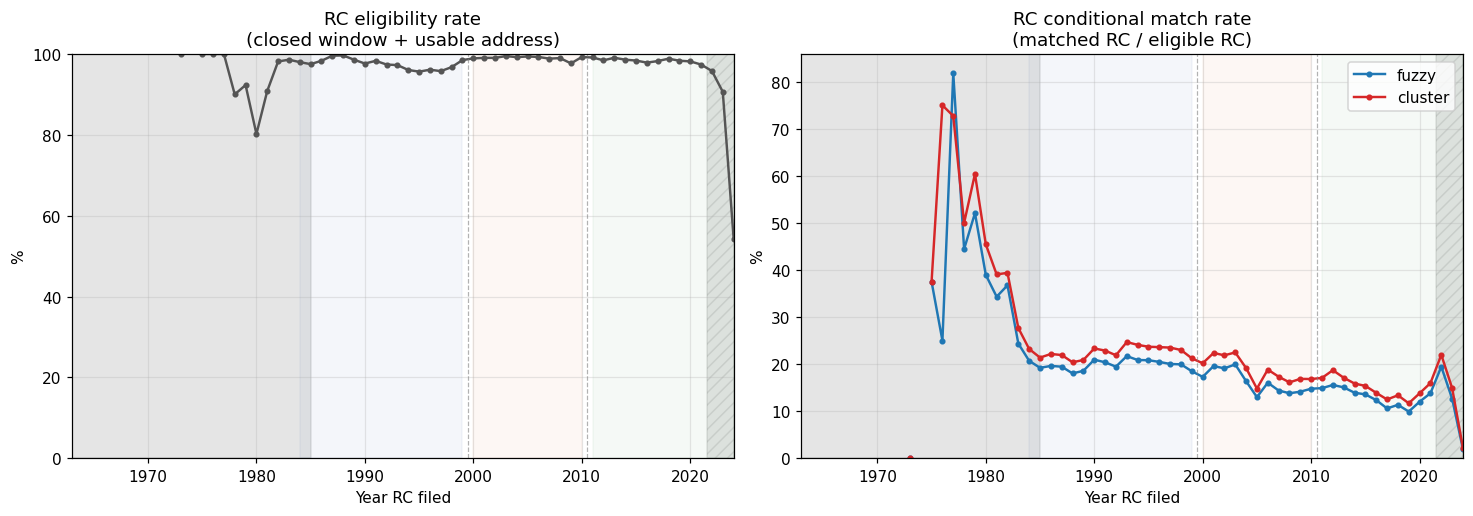

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)

elig = rate_r[rate_r["method"] == list(METHODS)[0]]
axes[0].plot(elig["year"], elig["elig_rate"], color="#555555", marker="o", ms=3, lw=1.6)
shade_eras(axes[0])
axes[0].set_title("RC eligibility rate\n(closed window + usable address)")
axes[0].set_xlabel("Year RC filed"); axes[0].set_ylabel("%"); axes[0].set_ylim(0, 100)

for name in METHODS:
    d = rate_r[rate_r["method"] == name]
    axes[1].plot(d["year"], d["conditional_rate"], marker="o", ms=3, lw=1.6,
                 color=METHOD_COLORS[name], label=name)
shade_eras(axes[1])
axes[1].set_title("RC conditional match rate\n(matched RC / eligible RC)")
axes[1].set_xlabel("Year RC filed"); axes[1].set_ylabel("%")
axes[1].set_ylim(bottom=0); axes[1].legend(loc="upper right")

for ax in axes:
    ax.set_xlim(YEAR_MIN, YEAR_MAX)
    mark_untrusted(ax, label=False)
plt.tight_layout(); plt.show()


In [16]:
# ---- Decade summary + save ----
dec = rate_r.copy()
dec["decade"] = (dec["year"] // 10 * 10).astype(int)
summary_r = (dec.groupby(["decade", "method"])
             .agg(n_total=("n_total", "sum"), n_eligible=("n_eligible", "sum"),
                  n_matched=("n_matched", "sum"), n_matched_eligible=("n_matched_eligible", "sum"))
             .reset_index())
summary_r["raw_rate_%"]         = (100*summary_r["n_matched"]/summary_r["n_total"]).round(2)
summary_r["elig_rate_%"]        = (100*summary_r["n_eligible"]/summary_r["n_total"]).round(1)
summary_r["conditional_rate_%"] = (100*summary_r["n_matched_eligible"]/summary_r["n_eligible"]).round(2)
display(summary_r)

out_r = Path("rc_match_rate_by_year.csv")
rate_r.sort_values(["method", "year"]).to_csv(out_r, index=False)
print("Saved", out_r.resolve())


,decade,method,n_total,n_eligible,n_matched,n_matched_eligible,raw_rate_%,elig_rate_%,conditional_rate_%
0,1960,cluster,0,0,0,0,NaN,NaN,NaN
1,1960,fuzzy,0,0,0,0,NaN,NaN,NaN
2,1970,cluster,100,94,55,55,55.00,94.0,58.51
3,1970,fuzzy,100,94,47,47,47.00,94.0,50.00
4,1980,cluster,36495,35950,8014,8014,21.96,98.5,22.29
5,1980,fuzzy,36495,35950,7124,7124,19.52,98.5,19.82
6,1990,cluster,47231,45796,10615,10615,22.47,97.0,23.18
7,1990,fuzzy,47231,45796,9302,9302,19.69,97.0,20.31
8,2000,cluster,33082,32764,6351,6351,19.20,99.0,19.38
9,2000,fuzzy,33082,32764,5489,5489,16.59,99.0,16.75


Saved C:\Users\PsyLab-9221\Documents\NLRB_project\nlrb-matching-cases\match_rate_over_time\rc_match_rate_by_year.csv


### Reading guide

- **Trust the centre, not the ends.** Pre-1985 is a CHIPS data ramp; the recent grey/hatched tail
  is right-censored (open RC windows the matcher drops) plus a partial final year. Both are shaded
  in every time plot — read only ≈1985–2018 at face value.
- **Section 5** is the headline rate to report. Because it is a share, the multi-decade decline
  in case volume is already divided out.
- **Section 6** tells you *why* the rate moves: a drop in the left panel (eligibility) at a
  system seam is a data-quality artifact of that filing system; a stable right panel
  (conditional rate) means matching itself is not the barrier. Here eligibility is flat ~98%,
  so the decline is substantive.
- **Section 7** checks the RC-supply confound — fewer petitions (falling faster than CA charges)
  mechanically means fewer matchable CA cases, independent of method quality.
- **Section 10** mirrors the whole analysis on the **R-side**: share of RC petitions
  with >=1 CA match. Its eligibility line carries the right-censoring (open RC windows),
  so recent years sag on the denominator — read the same trustworthy window.
- **Section 8** is the one-shot answer to "is a dataset a barrier": compare conditional rates
  across CHIPS / CATS / NxGen (with the end-of-series caveat).

Both matching methods are plotted throughout so you can see whether fuzzy and cluster agree on
the *trend* even where they differ on the *level*.